In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [19]:
df = pd.read_csv('data/store_sales.csv')
df

,date,store_id,sales,promo,school_holiday
0,2022-01-01,1,293,0,0
1,2022-01-02,1,330,0,0
2,2022-01-03,1,188,0,0
3,2022-01-04,1,249,0,0
4,2022-01-05,1,219,0,0
...,...,...,...,...,...
10955,2024-12-27,10,1012,0,0
10956,2024-12-28,10,1401,0,0
10957,2024-12-29,10,1613,1,0
10958,2024-12-30,10,689,0,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10960 entries, 0 to 10959
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   date            10960 non-null  str  
 1   store_id        10960 non-null  int64
 2   sales           10960 non-null  int64
 3   promo           10960 non-null  int64
 4   school_holiday  10960 non-null  int64
dtypes: int64(4), str(1)
memory usage: 428.3 KB


In [21]:
df.describe()

,store_id,sales,promo,school_holiday
count,10960.000000,10960.000000,10960.000000,10960.000000
mean,5.500000,559.986131,0.246168,0.121350
std,2.872412,213.590701,0.430797,0.326549
min,1.000000,170.000000,0.000000,0.000000
25%,3.000000,408.000000,0.000000,0.000000
50%,5.500000,519.500000,0.000000,0.000000
75%,8.000000,671.000000,0.000000,0.000000
max,10.000000,1915.000000,1.000000,1.000000


In [22]:
df.shape

(10960, 5)

In [23]:
df.isna().sum()

date              0
store_id          0
sales             0
promo             0
school_holiday    0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

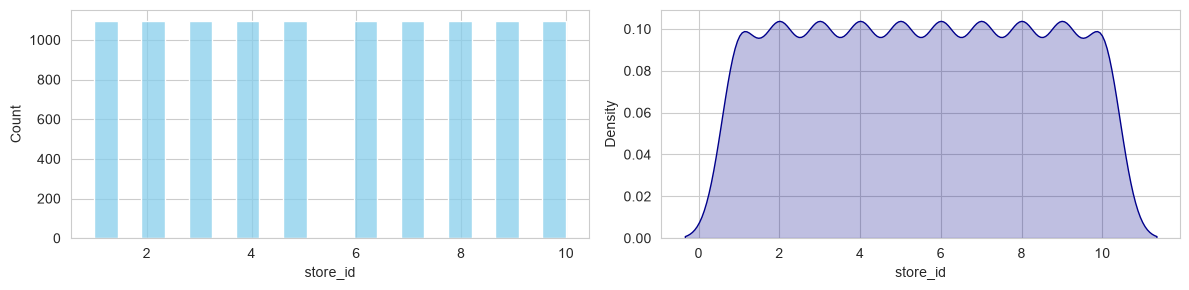

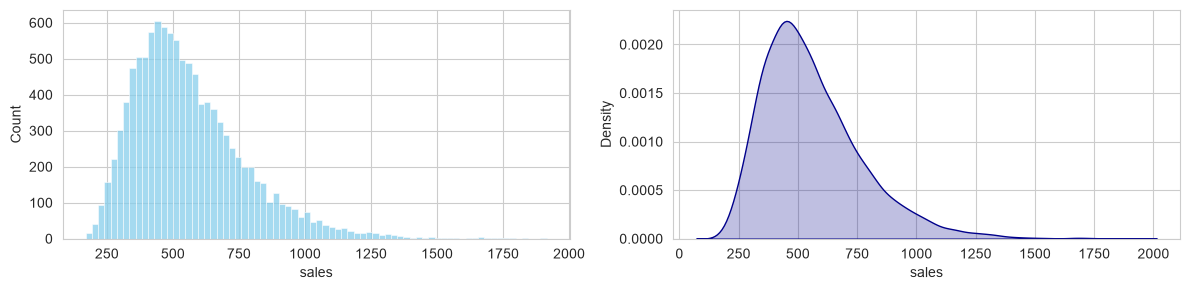

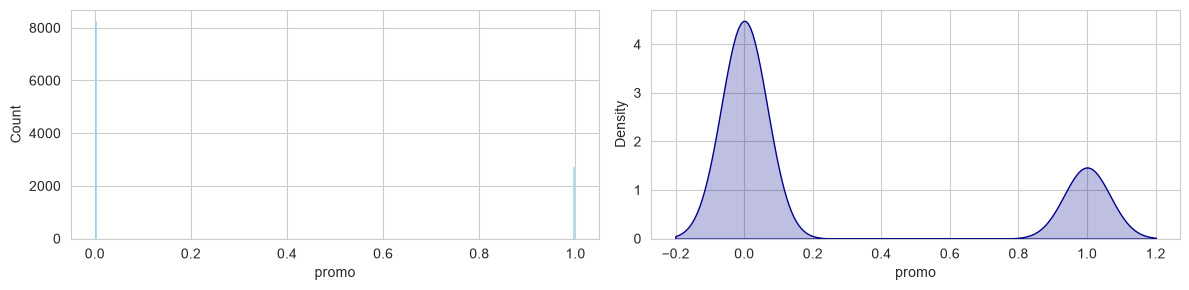

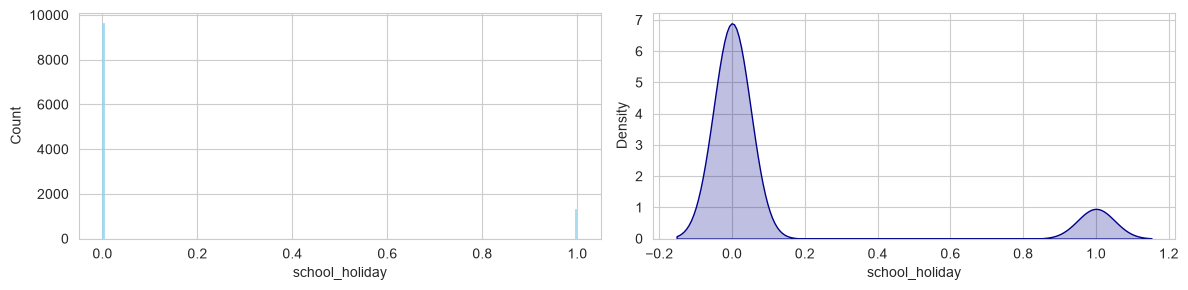

In [26]:
num_col = df.select_dtypes(include='number').columns.tolist()
for col in num_col:
    fig, axes = plt.subplots(1,2, figsize=(12,3))

    sns.histplot(df[col], ax = axes[0], color = 'skyblue')
    sns.kdeplot(df[col], ax = axes[1], color='darkblue', fill = True)
    plt.tight_layout()
    plt.show()

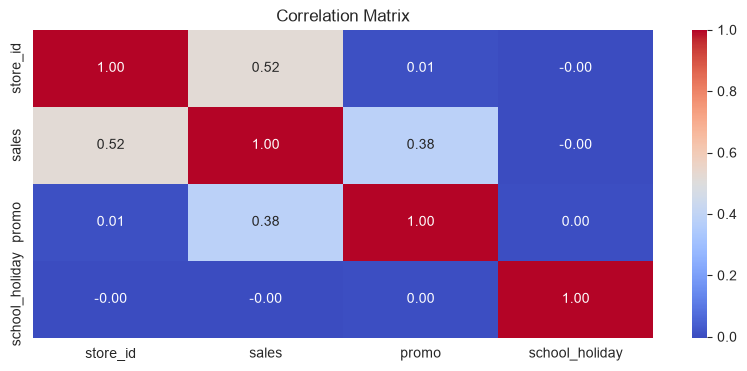

In [28]:
plt.figure(figsize=(10, 4))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


In [29]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['store_id', 'date']).reset_index(drop=True)

df['lag_1'] = df.groupby('store_id')['sales'].shift(1) 
df['lag_7'] = df.groupby('store_id')['sales'].shift(7) 
df['lag_14'] = df.groupby('store_id')['sales'].shift(14)
df['lag_28'] = df.groupby('store_id')['sales'].shift(28) 

df['rolling_mean_7'] = df.groupby('store_id')['sales'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df.groupby('store_id')['sales'].shift(1).rolling(7).std()
df['rolling_mean_30'] = df.groupby('store_id')['sales'].shift(1).rolling(30).mean()

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df_clean = df.dropna().reset_index(drop=True)

In [30]:
train_df = df_clean[df_clean['year'] < 2024]
test_df = df_clean[df_clean['year'] == 2024]

features = ['store_id', 'promo', 'school_holiday', 'day_of_week', 'month', 'is_weekend',
            'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']

X_train, y_train = train_df[features], train_df['sales']
X_test, y_test = test_df[features], test_df['sales']

print(f"Train Shape (2022-2023): {X_train.shape}")
print(f"Test Shape (2024):       {X_test.shape}")

Train Shape (2022-2023): (7000, 13)
Test Shape (2024):       (3660, 13)


In [32]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost (GPU)": XGBRegressor(device='cuda', tree_method='hist', random_state=42)
}

results = []

print("Running Out-of-Time Forecasting Benchmark (Trained 2022-2023, Evaluated on 2024)...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Test RMSE (Lower=Better)': rmse,
        'Test MAE (Sales Error)': mae,
        'Test R2 (Higher=Better)': r2
    })
    print(f"{name:<22} | RMSE: {rmse:.2f} | MAE: {mae:.2f} sales | R2: {r2:.4f}")

df_results = pd.DataFrame(results).sort_values(by='Test RMSE (Lower=Better)').reset_index(drop=True)
print("\n" + "="*75)
print("DAY 8 OUT-OF-TIME TIME-SERIES FORECASTING LEADERBOARD (2024 TEST)")
print("="*75)
print(df_results.to_string(index=False))

Running Out-of-Time Forecasting Benchmark (Trained 2022-2023, Evaluated on 2024)...

Linear Regression      | RMSE: 86.60 | MAE: 63.53 sales | R2: 0.8436
Ridge Regression       | RMSE: 86.69 | MAE: 63.54 sales | R2: 0.8433
Random Forest          | RMSE: 74.22 | MAE: 54.44 sales | R2: 0.8851
HistGradientBoosting   | RMSE: 73.92 | MAE: 56.20 sales | R2: 0.8860
LightGBM               | RMSE: 74.45 | MAE: 56.67 sales | R2: 0.8844
CatBoost               | RMSE: 72.56 | MAE: 55.85 sales | R2: 0.8902
XGBoost (GPU)          | RMSE: 79.54 | MAE: 60.07 sales | R2: 0.8681

DAY 8 OUT-OF-TIME TIME-SERIES FORECASTING LEADERBOARD (2024 TEST)
               Model  Test RMSE (Lower=Better)  Test MAE (Sales Error)  Test R2 (Higher=Better)
            CatBoost                 72.557961               55.853433                 0.890194
HistGradientBoosting                 73.920567               56.203569                 0.886031
       Random Forest                 74.221477               54.444734       

In [33]:
import pandas as pd

cat_model = CatBoostRegressor(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance (%)': cat_model.feature_importances_
}).sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

print("TOP 10 MOST INFLUENTIAL TIME-SERIES DRIVERS (CatBoost):")
print(df_imp.head(10).to_string(index=False))

TOP 10 MOST INFLUENTIAL TIME-SERIES DRIVERS (CatBoost):
        Feature  Importance (%)
          promo       25.151788
          month       13.295581
 rolling_mean_7       10.274780
     is_weekend        9.382929
    day_of_week        9.100943
          lag_7        8.283451
       store_id        6.503443
         lag_14        6.015867
rolling_mean_30        5.089647
         lag_28        3.184248
